# Notatnik Jupyter: Transkrypcja Audio Gitary na Tabulaturę

Ten notatnik przeprowadza proces od przygotowania danych GuitarSet, przez trening modelu CRNN, aż po ewaluację i generowanie plików MIDI z predykcji.

## Komórka 1: Importy i Globalna Konfiguracja

In [1]:
import os
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from IPython.display import clear_output
import time
import json
import preprocessing
import pytorch_dataset
import model as model_definition
import training_utils
import evaluation_utils
import plotting_utils
import mirdata

# --- Konfiguracja Ścieżek ---
DATA_HOME = os.path.join(os.getcwd(), "mir_datasets_storage")
OUTPUT_BASE_DIR = os.path.join(os.getcwd(), "processed_guitarset_data")
SEARCH_RUN_NAME = "training_defined_sets_run_v1"
MAIN_SEARCH_ARTIFACTS_DIR = os.path.join(OUTPUT_BASE_DIR, SEARCH_RUN_NAME)
HYPERPARAMETER_SETS_FILE = "hyperparameter_sets_v1.json"

# --- Parametry Przetwarzania Audio (STAŁE) ---
SAMPLE_RATE = 22050
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
MAX_FRETS = 20

# --- Parametry Danych i Podziału (STAŁE) ---
PROBLEMATIC_FILES = ["04_BN3-154-E_comp", "04_Jazz1-200-B_comp"]
VALIDATION_SPLIT_SIZE = 0.1
TEST_SPLIT_SIZE = 0.1
RANDOM_SEED = 42

# --- Parametry Modelu CRNN (STAŁE CNN) ---
CNN_INPUT_CHANNELS = 1
CNN_OUTPUT_CHANNELS_CONST = [32, 64, 128, 128, 128]
CNN_KERNEL_SIZES_CONST = [(3, 3), (3, 3), (3, 3), (3, 3), (3, 3)]
CNN_STRIDES_CONST = [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1)]
CNN_PADDINGS_CONST = [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1)]
CNN_POOLING_KERNELS_CONST = [(2, 1), (2, 1), (2, 1), (2, 1), (1, 1)]
CNN_POOLING_STRIDES_CONST = [(2, 1), (2, 1), (2, 1), (2, 1), (1, 1)]
CNN_FEATURE_DIM_PER_FRAME = None  # Obliczane dynamicznie

# --- Parametry Treningu (STAŁE, które nie są w pliku JSON) ---
NUM_EPOCHS = 500
BATCH_SIZE = 1
FRET_LOSS_WEIGHT = 1.0
FRET_NUM_CLASSES = MAX_FRETS + 2
FRET_IGNORE_INDEX_LOSS = None
PLOT_PREDICTIONS_EVERY_N_EPOCHS = 25
ONSET_PREDICTION_THRESHOLD = 0.5 
EARLY_STOPPING_PATIENCE = 25
CHECKPOINT_METRIC = 'val_onset_f1'
PRINT_EVERY_N_EPOCHS = 1
CLEAR_CONSOLE_EVERY_N_EPOCHS_WITHIN_RUN = 10

# --- WCZYTYWANIE ZESTAWÓW HIPERPARAMETRÓW Z PLIKU ---
param_grid = []
try:
    with open(HYPERPARAMETER_SETS_FILE, 'r', encoding='utf-8') as f:
        param_grid = json.load(f)
    print(f"Wczytano {len(param_grid)} zestawów hiperparametrów z pliku: {HYPERPARAMETER_SETS_FILE}")
    if param_grid:
        print("Przykładowy pierwszy wczytany zestaw:")
        print(f"  Opis: {param_grid[0].get('run_description', 'Brak opisu')}")
        print(f"  Parametry: { {k: v for k, v in param_grid[0].items() if k != 'run_description'} }")

except FileNotFoundError:
    print(
        f"BŁĄD: Plik z zestawami hiperparametrów '{HYPERPARAMETER_SETS_FILE}' nie został znaleziony. Utwórz go z podaną zawartością.")
except json.JSONDecodeError as e_json:
    print(f"BŁĄD: Plik '{HYPERPARAMETER_SETS_FILE}' zawiera niepoprawny format JSON. Szczegóły: {e_json}")
except Exception as e:
    print(f"BŁĄD podczas wczytywania zestawów hiperparametrów: {e}")

if not param_grid:
    print(
        "OSTRZEŻENIE: `param_grid` jest pusta. Przeszukiwanie nie zostanie wykonane. Sprawdź plik JSON i komunikaty błędów.")

# --- Parametry MIDI (stałe) ---
NUM_SAMPLES_TO_CONVERT_TO_MIDI = 1

# --- Globalne przygotowanie ---
print(f"\n--- Konfiguracja Projektu Załadowana (Tryb Przeszukiwania Hiperparametrów) ---")
print(f"Główny katalog przeszukiwania (MAIN_SEARCH_ARTIFACTS_DIR): {MAIN_SEARCH_ARTIFACTS_DIR}")

if not os.path.exists(OUTPUT_BASE_DIR): os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)
if not os.path.exists(MAIN_SEARCH_ARTIFACTS_DIR): os.makedirs(MAIN_SEARCH_ARTIFACTS_DIR, exist_ok=True)

# Zapisanie użytej listy param_grid dla referencji
loaded_grid_summary_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "loaded_param_grid_config.json")
with open(loaded_grid_summary_path, 'w', encoding='utf-8') as f_grid_cfg:  
    config_to_save = {
        'source_hyperparameter_file': HYPERPARAMETER_SETS_FILE,
        'loaded_param_grid': param_grid,
        'num_combinations_loaded': len(param_grid),
        'fixed_parameters_info': {
            'CNN_OUTPUT_CHANNELS_CONST': CNN_OUTPUT_CHANNELS_CONST,
            'FRET_LOSS_WEIGHT': FRET_LOSS_WEIGHT,
            'EARLY_STOPPING_PATIENCE': EARLY_STOPPING_PATIENCE,
            'PLOT_PREDICTIONS_EVERY_N_EPOCHS': PLOT_PREDICTIONS_EVERY_N_EPOCHS,
            'CLEAR_CONSOLE_EVERY_N_EPOCHS_WITHIN_RUN': CLEAR_CONSOLE_EVERY_N_EPOCHS_WITHIN_RUN
        }
    }
    json.dump(config_to_save, f_grid_cfg, indent=4, ensure_ascii=False)  # ensure_ascii dla polskich znaków
print(f"Zapisano konfigurację wczytanych zestawów parametrów do: {loaded_grid_summary_path}")


def jupyter_clear_output_func(wait=True):
    # Ta funkcja jest przekazywana do training_utils, aby mogła czyścić output wewnątrz przebiegu
    if CLEAR_CONSOLE_EVERY_N_EPOCHS_WITHIN_RUN > 0:
        clear_output(wait=wait)
    else:
        pass

Wczytano 15 zestawów hiperparametrów z pliku: hyperparameter_sets_v1.json
Przykładowy pierwszy wczytany zestaw:
  Opis: AggroReg_WD5e-4_D0.6_SchP8_LR2e-4_OLW10
  Parametry: {'LEARNING_RATE_INIT': 0.0002, 'ONSET_LOSS_WEIGHT': 10.0, 'ONSET_POS_WEIGHT_MANUAL_VALUE': 10.0, 'RNN_HIDDEN_SIZE': 768, 'RNN_LAYERS': 2, 'RNN_DROPOUT': 0.6, 'WEIGHT_DECAY': 0.0005, 'SCHEDULER_PATIENCE': 8, 'SCHEDULER_FACTOR': 0.3}

--- Konfiguracja Projektu Załadowana (Tryb Przeszukiwania Hiperparametrów) ---
Główny katalog przeszukiwania (MAIN_SEARCH_ARTIFACTS_DIR): C:\Users\lukig\Documents\Programming\music-transcription\python\v2\processed_guitarset_data\training_defined_sets_run_v1
Zapisano konfigurację wczytanych zestawów parametrów do: C:\Users\lukig\Documents\Programming\music-transcription\python\v2\processed_guitarset_data\training_defined_sets_run_v1\loaded_param_grid_config.json


## Komórka 2: Przygotowanie Danych (Podział ID i Preprocessing)

In [2]:
print("--- Etap 1: Przygotowanie i Podział Danych ---")
track_ids_split = preprocessing.prepare_track_splits(
    data_home=DATA_HOME,
    problematic_files=PROBLEMATIC_FILES,
    test_split_size=TEST_SPLIT_SIZE,
    validation_split_size=VALIDATION_SPLIT_SIZE,
    random_seed=RANDOM_SEED,
    output_base_dir_for_id_files=OUTPUT_BASE_DIR
)

if any(len(ids) > 0 for ids in track_ids_split.values()):
    print("\nUruchamianie preprocessingu (pominie już przetworzone pliki)...")
    preprocessing.preprocess_guitarset(
        data_home=DATA_HOME,
        output_base_dir=OUTPUT_BASE_DIR,
        track_ids_split=track_ids_split,
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    print("\nPreprocessing zakończony lub pliki już istniały.")
else:
    print("Brak utworów do przetworzenia. Preprocessing nie został uruchomiony.")

--- Etap 1: Przygotowanie i Podział Danych ---
Znaleziono 360 wszystkich track_id w GuitarSet.
Liczba track_id po usunięciu problematycznych plików: 358

Podział na zbiory:
  Treningowy: 286 utworów
  Walidacyjny: 36 utworów
  Testowy: 36 utworów

Zapisano listy track_id dla każdego zbioru w katalogu: C:\Users\lukig\Documents\Programming\music-transcription\python\v2\processed_guitarset_data

Uruchamianie preprocessingu (pominie już przetworzone pliki)...
Rozpoczynanie preprocessingu GuitarSet.
Katalog danych (data_home): C:\Users\lukig\Documents\Programming\music-transcription\python\v2\mir_datasets_storage
Główny katalog wyjściowy: C:\Users\lukig\Documents\Programming\music-transcription\python\v2\processed_guitarset_data

Przetwarzanie zbioru: train (286 utworów)


Processing train: 100%|██████████| 286/286 [00:00<00:00, 15881.42track/s]




Przetwarzanie zbioru: validation (36 utworów)


Processing validation: 100%|██████████| 36/36 [00:00<00:00, 18061.60track/s]




Przetwarzanie zbioru: test (36 utworów)


Processing test: 100%|██████████| 36/36 [00:00<00:00, 24009.37track/s]



--- Podsumowanie preprocessingu ---
Liczba wszystkich utworów przeznaczonych do przetworzenia (po podziale): 358
  Zbiór train:
    Nowo przetworzono: 0
    Pominięto (już istniały): 286
    Błędy: 0
  Zbiór validation:
    Nowo przetworzono: 0
    Pominięto (już istniały): 36
    Błędy: 0
  Zbiór test:
    Nowo przetworzono: 0
    Pominięto (już istniały): 36
    Błędy: 0
Przetworzone dane zostały zapisane w katalogu: C:\Users\lukig\Documents\Programming\music-transcription\python\v2\processed_guitarset_data

Preprocessing zakończony lub pliki już istniały.


## Komórka 3: Tworzenie Dataset i DataLoader

In [3]:
print("\n--- Etap 2: Tworzenie Datasetów i DataLoaderów ---")
train_dataset, validation_dataset, test_dataset = None, None, None
train_dataloader, validation_dataloader, test_dataloader = None, None, None

# Sprawdź, czy są jakiekolwiek ID utworów do przetworzenia
if any(track_ids_split.get(split_name) for split_name in ['train', 'validation', 'test']):
    try:
        # --- Zbiór treningowy z augmentacjami ---
        if track_ids_split.get('train'):
            train_dataset = pytorch_dataset.GuitarSetTabDataset(
                data_base_dir=OUTPUT_BASE_DIR, # Katalog z _ids.txt i przetworzonymi .pt dla val/test
                split='train',
                data_home=DATA_HOME,           # <<<< NOWY PARAMETR: ścieżka do oryginalnego GuitarSet
                hop_length=HOP_LENGTH,
                sample_rate=SAMPLE_RATE,
                max_frets=MAX_FRETS,
                n_fft=N_FFT,
                n_mels=N_MELS,
                labels_transform_func=pytorch_dataset.create_frame_labels,
                # Parametry Augmentacji
                apply_audio_augmentations=True,
                p_time_stretch=0.5, time_stretch_range=(0.85, 1.15),
                p_add_noise=0.5, noise_level_range=(0.0001, 0.002),
                p_random_gain=0.5, gain_range=(0.7, 1.3),
                apply_specaugment=True,
                spec_time_mask_max_percentage=0.08,
                spec_freq_mask_max_percentage=0.12
            )
            if len(train_dataset) > 0:
                print(f"Rozmiar zbioru treningowego: {len(train_dataset)}")
            else:
                print("Zbiór treningowy jest pusty (sprawdź ścieżki i logikę wczytywania audio).")
                train_dataset = None

        # --- Zbiór walidacyjny bez augmentacji ---
        if track_ids_split.get('validation'):
            validation_dataset = pytorch_dataset.GuitarSetTabDataset(
                data_base_dir=OUTPUT_BASE_DIR,
                split='validation',
                data_home=DATA_HOME, # Przekazujemy, ale nie będzie używane przez mirdata dla 'validation'
                hop_length=HOP_LENGTH,
                sample_rate=SAMPLE_RATE,
                max_frets=MAX_FRETS,
                n_fft=N_FFT,
                n_mels=N_MELS,
                labels_transform_func=pytorch_dataset.create_frame_labels,
                apply_audio_augmentations=False,
                apply_specaugment=False
            )
            if len(validation_dataset) > 0:
                print(f"Rozmiar zbioru walidacyjnego: {len(validation_dataset)}")
            else:
                print("Zbiór walidacyjny jest pusty.")
                validation_dataset = None
        else:
            print("Brak zdefiniowanych ID dla zbioru walidacyjnego.")

        # --- Zbiór testowy bez augmentacji ---
        if track_ids_split.get('test'):
            test_dataset = pytorch_dataset.GuitarSetTabDataset(
                data_base_dir=OUTPUT_BASE_DIR,
                split='test',
                data_home=DATA_HOME, # Przekazujemy, ale nie będzie używane przez mirdata dla 'test'
                hop_length=HOP_LENGTH,
                sample_rate=SAMPLE_RATE,
                max_frets=MAX_FRETS,
                n_fft=N_FFT,
                n_mels=N_MELS,
                labels_transform_func=pytorch_dataset.create_frame_labels,
                apply_audio_augmentations=False,
                apply_specaugment=False
            )
            if len(test_dataset) > 0:
                print(f"Rozmiar zbioru testowego: {len(test_dataset)}")
            else:
                print("Zbiór testowy jest pusty.")
                test_dataset = None
        else:
            print("Brak zdefiniowanych ID dla zbioru testowego.")

        # Tworzenie DataLoaderów
        if train_dataset and len(train_dataset) > 0:
            train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
        if validation_dataset and len(validation_dataset) > 0:
            validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
        if test_dataset and len(test_dataset) > 0:
            test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
        
        if train_dataloader or validation_dataloader or test_dataloader:
            print(f"\nDataLoadery utworzone (BATCH_SIZE = {BATCH_SIZE}).")
        else:
            print("\nNie utworzono żadnych DataLoaderów.")

    except FileNotFoundError as e:
        print(f"BŁĄD KRYTYCZNY podczas tworzenia Dataset/DataLoader: {e}")
    except Exception as e:
        print(f"Nieoczekiwany błąd podczas tworzenia Dataset/DataLoader: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Brak list ID utworów (track_ids_split) dla któregokolwiek podziału, pomijam tworzenie Datasetów i DataLoaderów.")


--- Etap 2: Tworzenie Datasetów i DataLoaderów ---
Rozmiar zbioru treningowego: 286
Rozmiar zbioru walidacyjnego: 36
Rozmiar zbioru testowego: 36

DataLoadery utworzone (BATCH_SIZE = 1).


## Komórka 4: Wizualizacja Próbki Danych (Opcjonalnie)


--- Etap 3: Wizualizacja Próbki Danych (Opcjonalnie) ---

Generowanie wykresów dla próbki...


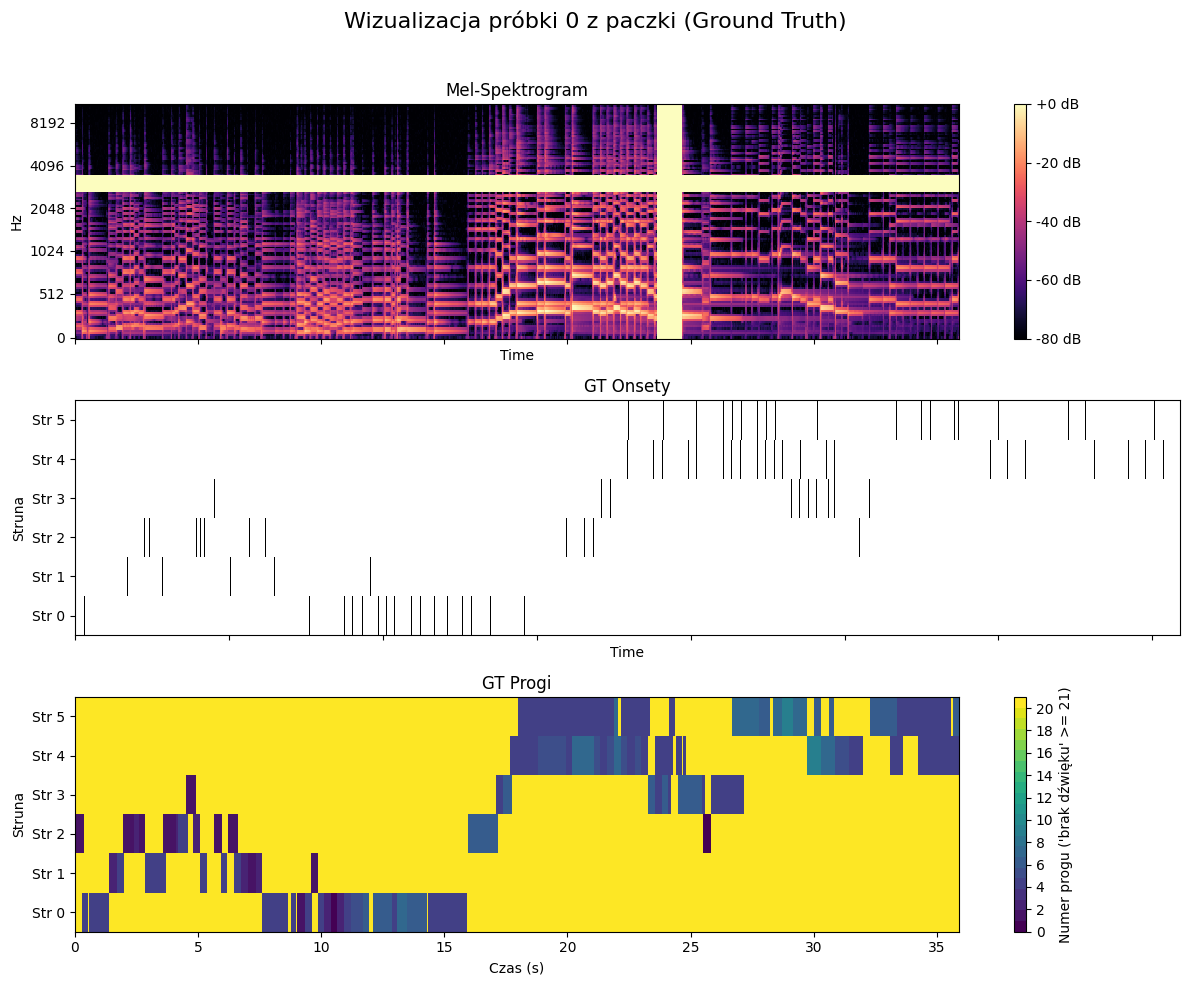


Generowanie szczegółów tekstowych dla próbki...

--- Szczegóły tekstowe dla próbki 0 z paczki (Ground Truth) ---

1. Spektrogram (Log-Mel):
   Kształt: torch.Size([128, 1546]), Typ: torch.float32, Min: -80.00, Max: 0.00, Śr: -54.03
   Fragment: [[-71.72547  -68.8743   -69.06251  -72.73241  -67.306946]
 [-65.06359  -61.85097  -61.255848 -61.373043 -62.062695]
 [-53.608917 -48.682198 -49.330574 -49.371826 -49.591805]
 [-46.078632 -43.367226 -48.731934 -52.51393  -54.03527 ]
 [-38.80449  -36.16964  -36.26003  -36.471912 -36.799084]]

2. Etykiety Onsetów (GT):
   Kształt: torch.Size([1546, 6]), Typ: torch.float32, Suma (aktywnych onsetów): 116
   Początek (transponowany): [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
   Koniec (transponowany): [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

3. Etykiety Progów (GT - indeksy):
   Kształt: torch.Size([1546, 6]), Typ: t

In [4]:
print("\n--- Etap 3: Wizualizacja Próbki Danych (Opcjonalnie) ---")
if train_dataloader:
    try:
        features_batch, labels_batch_tuple = next(iter(train_dataloader))
        if features_batch.nelement() > 0:
            print("\nGenerowanie wykresów dla próbki...")
            plotting_utils.plot_batch_sample(
                features=features_batch, labels_tuple=labels_batch_tuple,
                sample_idx=0, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                max_frets_for_display=MAX_FRETS + 1, num_strings=6
            )
            print("\nGenerowanie szczegółów tekstowych dla próbki...")
            plotting_utils.print_batch_sample_details(
                features=features_batch, labels_tuple=labels_batch_tuple,
                sample_idx=0, max_frames_to_show=5, max_strings_to_show=6
            )
        else:
            print("Paczka danych z train_dataloader jest pusta.")
    except StopIteration:
        print("Train DataLoader jest pusty.")
    except Exception as e:
        print(f"Błąd podczas wizualizacji danych: {e}")
else:
    print("Train_dataloader nie jest dostępny do inspekcji.")

## Komórka 5: Pętla Przeszukiwania Hiperparametrów, Inicjalizacja Modelu, Trening i Ewaluacja

In [ ]:
import numpy as np

print(f"\n{'=' * 20} ROZPOCZYNANIE PRZESZUKIWANIA HIPERPARAMETRÓW {'=' * 20}")

all_search_results = []  # Lista do przechowywania wyników z każdego przebiegu

# Sprawdzenie, czy param_grid zostało poprawnie wczytane
if not param_grid:
    print("BŁĄD KRYTYCZNY: `param_grid` jest pusta. Sprawdź wczytywanie pliku JSON w Komórce 1.")
    raise ValueError("param_grid nie może być pusta do rozpoczęcia przeszukiwania.")

# Pętla po zdefiniowanych kombinacjach hiperparametrów
for run_idx, params_combo in enumerate(param_grid):
    run_id = run_idx + 1

    # Czyszczenie outputu co 10 przebiegów (jeśli to nie pierwszy przebieg)
    if run_idx > 0 and run_idx % CLEAR_CONSOLE_EVERY_N_EPOCHS_WITHIN_RUN == 0:
        clear_output(wait=True)
        print(f"Output konsoli wyczyszczony. Kontynuacja przeszukiwania...")
        print(f"Aktualnie przetwarzany: Przebieg {run_id}/{len(param_grid)}")

    print(f"\n\n{'=' * 30} ROZPOCZYNANIE PRZEBIEGU {run_id}/{len(param_grid)} {'=' * 30}")
    print(f"Używane parametry dla tego przebiegu: {params_combo}")

    # --- Dynamiczne ustawianie parametrów dla bieżącego przebiegu ---
    LEARNING_RATE = params_combo['LEARNING_RATE_INIT']
    ONSET_LOSS_WEIGHT = params_combo['ONSET_LOSS_WEIGHT']
    ONSET_POS_WEIGHT_MANUAL_VALUE = params_combo['ONSET_POS_WEIGHT_MANUAL_VALUE']
    CURRENT_RNN_HIDDEN_SIZE = params_combo['RNN_HIDDEN_SIZE']
    CURRENT_RNN_LAYERS = params_combo['RNN_LAYERS']
    RNN_DROPOUT = params_combo['RNN_DROPOUT']
    WEIGHT_DECAY = params_combo['WEIGHT_DECAY']
    CURRENT_SCHEDULER_PATIENCE = params_combo['SCHEDULER_PATIENCE']
    CURRENT_SCHEDULER_FACTOR = params_combo['SCHEDULER_FACTOR']

    run_description = params_combo.get('run_description', f'run_{run_id}')
    current_run_folder_name = f"run_{run_id}_{run_description.replace(' ', '_').replace('/', '-').replace(':', '').replace(',', '')[:50]}"

    CURRENT_ARTIFACTS_DIR = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, current_run_folder_name)
    CURRENT_LOG_FILE_PATH = os.path.join(CURRENT_ARTIFACTS_DIR, f"training_log.txt")
    CURRENT_OUTPUT_MIDI_DIR = os.path.join(CURRENT_ARTIFACTS_DIR, "midi_transcriptions")
    CURRENT_TEXT_TAB_DIR = os.path.join(CURRENT_ARTIFACTS_DIR, "text_tablatures")

    if not os.path.exists(CURRENT_ARTIFACTS_DIR): os.makedirs(CURRENT_ARTIFACTS_DIR, exist_ok=True)
    if not os.path.exists(CURRENT_OUTPUT_MIDI_DIR): os.makedirs(CURRENT_OUTPUT_MIDI_DIR, exist_ok=True)
    if not os.path.exists(CURRENT_TEXT_TAB_DIR): os.makedirs(CURRENT_TEXT_TAB_DIR, exist_ok=True)

    print(f"--- Konfiguracja dla przebiegu {run_id} ({current_run_folder_name}) ---")
    print(f"  Katalog artefaktów: {CURRENT_ARTIFACTS_DIR}")
    # Logowanie kluczowych parametrów (reszta będzie w pliku logu i configu przebiegu)
    print(f"  LR: {LEARNING_RATE}, OLW: {ONSET_LOSS_WEIGHT}, OPW: {ONSET_POS_WEIGHT_MANUAL_VALUE}")
    print(f"  RNN_H: {CURRENT_RNN_HIDDEN_SIZE}, RNN_L: {CURRENT_RNN_LAYERS}, RNN_D: {RNN_DROPOUT}")
    print(f"  WD: {WEIGHT_DECAY}, SchP: {CURRENT_SCHEDULER_PATIENCE}, SchF: {CURRENT_SCHEDULER_FACTOR}")
    print("-" * 50)

    # --- Etap Modelu: Definicja i Inicjalizacja ---
    model_run = None
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    calculated_cnn_feature_dim_run = None  # Inicjalizacja na początku każdej iteracji pętli
    if N_MELS:  # N_MELS jest z globalnej konfiguracji (Komórka 1)
        try:
            temp_cnn_run = model_definition.TabCNN(
                input_channels=CNN_INPUT_CHANNELS, output_channels_list=CNN_OUTPUT_CHANNELS_CONST,
                kernel_sizes=CNN_KERNEL_SIZES_CONST, strides=CNN_STRIDES_CONST, paddings=CNN_PADDINGS_CONST,
                pooling_kernels=CNN_POOLING_KERNELS_CONST, pooling_strides=CNN_POOLING_STRIDES_CONST
            )
            with torch.no_grad():
                dummy_input_cnn_run = torch.randn(1, CNN_INPUT_CHANNELS, N_MELS, 32)
                dummy_output_cnn_run = temp_cnn_run(dummy_input_cnn_run)
                calculated_cnn_feature_dim_run = temp_cnn_run.output_channels * dummy_output_cnn_run.shape[2]
        except Exception as e_cnn_dim:
            error_msg_cnn = f"Błąd podczas obliczania wymiaru cech z CNN dla przebiegu {run_id}: {e_cnn_dim}"
            print(error_msg_cnn)
            all_search_results.append(
                {"run_index": run_id, "params_combo": params_combo, "status": "CNN_DIM_ERROR", "error": str(e_cnn_dim)})
            summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
            with open(summary_file_path, "a", encoding="utf-8") as f_summary:
                f_summary.write(json.dumps(all_search_results[-1]) + "\n")
            continue

    if not N_MELS or calculated_cnn_feature_dim_run is None:
        error_msg_init_pre = "N_MELS nie jest zdefiniowane lub CNN_FEATURE_DIM nie obliczone. Pomijam przebieg."
        print(error_msg_init_pre)
        all_search_results.append({"run_index": run_id, "params_combo": params_combo, "status": "MODEL_INIT_PRE_ERROR",
                                   "error": error_msg_init_pre})
        summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
        with open(summary_file_path, "a", encoding="utf-8") as f_summary: f_summary.write(
            json.dumps(all_search_results[-1]) + "\n")
        continue

    try:
        model_run = model_definition.GuitarTabCRNN(
            num_frames_rnn_input_dim=calculated_cnn_feature_dim_run,
            rnn_hidden_size=CURRENT_RNN_HIDDEN_SIZE, rnn_layers=CURRENT_RNN_LAYERS, rnn_dropout=RNN_DROPOUT,
            num_strings=6, max_frets=MAX_FRETS,
            cnn_input_channels=CNN_INPUT_CHANNELS, cnn_output_channels_list=CNN_OUTPUT_CHANNELS_CONST,
            cnn_kernel_sizes=CNN_KERNEL_SIZES_CONST, cnn_strides=CNN_STRIDES_CONST, cnn_paddings=CNN_PADDINGS_CONST,
            cnn_pooling_kernels=CNN_POOLING_KERNELS_CONST, cnn_pooling_strides=CNN_POOLING_STRIDES_CONST
        )
        model_run.to(device)
        print(f"Model GuitarTabCRNN zdefiniowany dla przebiegu {run_id}.")
    except Exception as e_model_init:
        error_msg_model = f"Błąd podczas inicjalizacji modelu dla przebiegu {run_id}: {e_model_init}"
        print(error_msg_model)
        all_search_results.append({"run_index": run_id, "params_combo": params_combo, "status": "MODEL_INIT_ERROR",
                                   "error": str(e_model_init)})
        summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
        with open(summary_file_path, "a", encoding="utf-8") as f_summary:
            f_summary.write(json.dumps(all_search_results[-1]) + "\n")
        continue

    # --- Etap Treningu ---
    history_run = None
    ONSET_POS_WEIGHT_TENSOR_RUN = None

    # Używamy ONSET_POS_WEIGHT_MANUAL_VALUE bezpośrednio, ponieważ usunęliśmy opcję 'None' z siatki
    if isinstance(ONSET_POS_WEIGHT_MANUAL_VALUE, (int, float)) and ONSET_POS_WEIGHT_MANUAL_VALUE > 0:
        ONSET_POS_WEIGHT_TENSOR_RUN = torch.tensor([ONSET_POS_WEIGHT_MANUAL_VALUE], device=device)
        effective_onset_pos_weight_used_for_log_run = ONSET_POS_WEIGHT_TENSOR_RUN.item()
    else:
        # Ta sytuacja nie powinna wystąpić, jeśli plik JSON jest poprawny
        ONSET_POS_WEIGHT_TENSOR_RUN = None
        effective_onset_pos_weight_used_for_log_run = "None (Błąd w config JSON!)"
        print(
            f"OSTRZEŻENIE: ONSET_POS_WEIGHT_MANUAL_VALUE ({ONSET_POS_WEIGHT_MANUAL_VALUE}) z pliku JSON jest niepoprawne. Użyto domyślnego pos_weight.")

    combined_criterion_run = training_utils.CombinedLoss(
        onset_pos_weight=ONSET_POS_WEIGHT_TENSOR_RUN,
        fret_ignore_index=FRET_IGNORE_INDEX_LOSS,
        onset_loss_weight=ONSET_LOSS_WEIGHT, fret_loss_weight=FRET_LOSS_WEIGHT
    ).to(device)

    optimizer_run = optim.AdamW(model_run.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    scheduler_run = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_run, mode='max', factor=CURRENT_SCHEDULER_FACTOR, patience=CURRENT_SCHEDULER_PATIENCE
    )

    current_run_training_config = {
        "NUM_EPOCHS": NUM_EPOCHS, "LEARNING_RATE_INIT": LEARNING_RATE, "BATCH_SIZE": BATCH_SIZE,
        "OPTIMIZER_TYPE": "AdamW", "WEIGHT_DECAY": WEIGHT_DECAY,
        "SCHEDULER_TYPE": "ReduceLROnPlateau", "SCHEDULER_PATIENCE": CURRENT_SCHEDULER_PATIENCE,
        "SCHEDULER_FACTOR": CURRENT_SCHEDULER_FACTOR,
        "ONSET_LOSS_WEIGHT": ONSET_LOSS_WEIGHT, "FRET_LOSS_WEIGHT": FRET_LOSS_WEIGHT,
        "ONSET_POS_WEIGHT_USED": effective_onset_pos_weight_used_for_log_run,
        "FRET_NUM_CLASSES": FRET_NUM_CLASSES, "FRET_IGNORE_INDEX_LOSS": FRET_IGNORE_INDEX_LOSS,
        "ARTIFACTS_DIR": CURRENT_ARTIFACTS_DIR, "LOG_FILE_PATH": CURRENT_LOG_FILE_PATH,
        "CLEAR_CONSOLE_EVERY_N_EPOCHS": 10,
        "CLEAR_OUTPUT_FUNC": jupyter_clear_output_func if 10 > 0 else None,
        "PLOT_PREDICTIONS_EVERY_N_EPOCHS": PLOT_PREDICTIONS_EVERY_N_EPOCHS,
        "ONSET_PREDICTION_THRESHOLD": ONSET_PREDICTION_THRESHOLD,
        "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE, "CHECKPOINT_METRIC": CHECKPOINT_METRIC,
        "SAMPLE_RATE": SAMPLE_RATE, "HOP_LENGTH": HOP_LENGTH, "N_MELS": N_MELS,
        "MAX_FRETS": MAX_FRETS, "N_FFT": N_FFT,
        "MODEL_CLASS": model_run.__class__.__name__,
        "CNN_INPUT_CHANNELS": CNN_INPUT_CHANNELS, "CNN_OUTPUT_CHANNELS": CNN_OUTPUT_CHANNELS_CONST,
        "CNN_KERNEL_SIZES": CNN_KERNEL_SIZES_CONST, "CNN_STRIDES": CNN_STRIDES_CONST,
        "CNN_PADDINGS": CNN_PADDINGS_CONST, "CNN_POOLING_KERNELS": CNN_POOLING_KERNELS_CONST,
        "CNN_POOLING_STRIDES": CNN_POOLING_STRIDES_CONST,
        "CNN_FEATURE_DIM_PER_FRAME": calculated_cnn_feature_dim_run,
        "RNN_HIDDEN_SIZE": CURRENT_RNN_HIDDEN_SIZE, "RNN_LAYERS": CURRENT_RNN_LAYERS, "RNN_DROPOUT": RNN_DROPOUT,
        "RANDOM_SEED_DATA_SPLIT": RANDOM_SEED,
        "RUN_DESCRIPTION": run_description
    }

    print(f"Rozpoczynanie treningu dla przebiegu {run_id} ({current_run_folder_name}). Logi w: {CURRENT_LOG_FILE_PATH}")
    start_time_run = time.time()
    try:
        history_run = training_utils.run_training_loop(
            model=model_run, device=device,
            train_dataloader=train_dataloader, validation_dataloader=validation_dataloader,
            optimizer=optimizer_run, scheduler=scheduler_run, combined_criterion=combined_criterion_run,
            training_config_dict=current_run_training_config,
            sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            validation_dataset_for_plotting=validation_dataset
        )
    except Exception as e_train:
        error_msg_train = f"BŁĄD KRYTYCZNY podczas treningu przebiegu {run_id}: {e_train}"
        print(error_msg_train)
        all_search_results.append(
            {"run_index": run_id, "params_combo": params_combo, "status": "TRAINING_ERROR", "error": str(e_train),
             "run_folder_name": current_run_folder_name})
        summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
        with open(summary_file_path, "a", encoding="utf-8") as f_summary:
            f_summary.write(json.dumps(all_search_results[-1]) + "\n")
        continue

    end_time_run = time.time()
    run_duration_minutes = (end_time_run - start_time_run) / 60
    print(f"Zakończono trening dla przebiegu {run_id}. Czas trwania: {run_duration_minutes:.2f} minut.")

    if history_run:
        history_plot_path_run = os.path.join(CURRENT_ARTIFACTS_DIR, "training_history_summary_final.png")
        plotting_utils.plot_training_history(history_run, save_path=history_plot_path_run)

    # --- Etap Ewaluacji dla przebiegu ---
    print(f"\n--- Etap Ewaluacji dla przebiegu {run_id} ---")
    best_model_path_run = os.path.join(CURRENT_ARTIFACTS_DIR, "best_model.pth")
    loaded_model_for_eval_run = None

    model_init_params_run = {
        'num_frames_rnn_input_dim': calculated_cnn_feature_dim_run,
        'rnn_hidden_size': CURRENT_RNN_HIDDEN_SIZE, 'rnn_layers': CURRENT_RNN_LAYERS, 'rnn_dropout': RNN_DROPOUT,
        'num_strings': 6, 'max_frets': MAX_FRETS,
        'cnn_input_channels': CNN_INPUT_CHANNELS, 'cnn_output_channels_list': CNN_OUTPUT_CHANNELS_CONST,
        'cnn_kernel_sizes': CNN_KERNEL_SIZES_CONST, 'cnn_strides': CNN_STRIDES_CONST,
        'cnn_paddings': CNN_PADDINGS_CONST, 'cnn_pooling_kernels': CNN_POOLING_KERNELS_CONST,
        'cnn_pooling_strides': CNN_POOLING_STRIDES_CONST
    }

    if os.path.exists(best_model_path_run):
        loaded_model_for_eval_run = evaluation_utils.load_best_model(
            model_definition.GuitarTabCRNN, model_init_params_run, best_model_path_run, device
        )
    else:
        print(f"Ostrzeżenie: Nie znaleziono pliku best_model.pth w {CURRENT_ARTIFACTS_DIR} dla przebiegu {run_id}.")

    best_f1_val_run = 0.0;
    p_at_best_f1_val_run = 0.0;
    r_at_best_f1_val_run = 0.0
    optimal_threshold_for_best_f1_val_run = current_run_training_config["ONSET_PREDICTION_THRESHOLD"]
    stopped_epoch_run = 0
    val_loss_total_at_best_f1 = float('inf')

    if history_run and 'val_onset_f1_optimal_thresh' in history_run and history_run['val_onset_f1_optimal_thresh']:
        history_f1_opt = history_run['val_onset_f1_optimal_thresh']
        if history_f1_opt:
            best_f1_idx = np.argmax(history_f1_opt)
            best_f1_val_run = history_f1_opt[best_f1_idx]
            if 'val_onset_precision_optimal_thresh' in history_run and len(
                    history_run['val_onset_precision_optimal_thresh']) > best_f1_idx:
                p_at_best_f1_val_run = history_run['val_onset_precision_optimal_thresh'][best_f1_idx]
            if 'val_onset_recall_optimal_thresh' in history_run and len(
                    history_run['val_onset_recall_optimal_thresh']) > best_f1_idx:
                r_at_best_f1_val_run = history_run['val_onset_recall_optimal_thresh'][best_f1_idx]
            if 'val_optimal_onset_threshold_epoch' in history_run and len(
                    history_run['val_optimal_onset_threshold_epoch']) > best_f1_idx:
                optimal_threshold_for_best_f1_val_run = history_run['val_optimal_onset_threshold_epoch'][best_f1_idx]
            if 'val_total_loss' in history_run and len(history_run['val_total_loss']) > best_f1_idx:
                val_loss_total_at_best_f1 = history_run['val_total_loss'][best_f1_idx]
        if 'train_total_loss' in history_run:
            stopped_epoch_run = len(history_run['train_total_loss'])

    print(
        f"Najlepszy Val Onset F1 (Opt Th) dla przebiegu {run_id}: {best_f1_val_run:.4f} (P: {p_at_best_f1_val_run:.4f}, R: {r_at_best_f1_val_run:.4f} przy Th={optimal_threshold_for_best_f1_val_run:.2f})")

    test_metrics_results_run = "N/A"
    if loaded_model_for_eval_run and test_dataloader:
        print(f"Ewaluacja na zbiorze testowym z progiem: {optimal_threshold_for_best_f1_val_run:.2f}")
        test_metrics_results_run = evaluation_utils.evaluate_model_on_test_set(
            model_to_eval=loaded_model_for_eval_run, test_dataloader=test_dataloader, device=device,
            fret_num_classes=FRET_NUM_CLASSES,
            optimal_onset_threshold=optimal_threshold_for_best_f1_val_run
        )

        if test_dataset and len(test_dataset) > 0:
            evaluation_utils.generate_text_tablature_comparison(
                model_to_eval=loaded_model_for_eval_run, dataset=test_dataset, device=device,
                sample_indices=list(range(min(NUM_SAMPLES_TO_CONVERT_TO_MIDI, len(test_dataset)))),
                optimal_onset_threshold=optimal_threshold_for_best_f1_val_run,
                sr=SAMPLE_RATE, hop_length=HOP_LENGTH, max_frets=MAX_FRETS, num_strings=6,
                output_dir=CURRENT_TEXT_TAB_DIR,
                frames_per_slot=4, slot_char_width=3, line_break_after_slots=20
            )

            if evaluation_utils.PRETTY_MIDI_AVAILABLE:
                guitarset_mirdata_loader_run = None  # Zmienna lokalna dla przebiegu
                try:
                    guitarset_mirdata_loader_run = mirdata.initialize('guitarset', data_home=DATA_HOME)
                except Exception as e:
                    print(f"Ostrzeżenie: Nie udało się zainicjalizować mirdata dla przebiegu {run_id}. Błąd: {e}")

                evaluation_utils.generate_midi_from_predictions(
                    model_to_eval=loaded_model_for_eval_run, dataset=test_dataset, device=device,
                    sample_indices=list(range(min(NUM_SAMPLES_TO_CONVERT_TO_MIDI, len(test_dataset)))),
                    optimal_onset_threshold=optimal_threshold_for_best_f1_val_run,
                    sr=SAMPLE_RATE, hop_length=HOP_LENGTH, max_frets=MAX_FRETS,
                    output_midi_dir=CURRENT_OUTPUT_MIDI_DIR,
                    mirdata_data_home=DATA_HOME,
                    guitarset_loader_instance=guitarset_mirdata_loader_run
                )

    run_summary = {
        "run_index": run_id, "run_folder_name": current_run_folder_name, "params_combo": params_combo,
        "best_val_onset_f1_optimal_thresh": best_f1_val_run,
        "val_precision_at_best_f1": p_at_best_f1_val_run,
        "val_recall_at_best_f1": r_at_best_f1_val_run,
        "optimal_threshold_for_best_val_f1": optimal_threshold_for_best_f1_val_run,
        "val_loss_total_at_best_f1": val_loss_total_at_best_f1,
        "cnn_feature_dim_per_frame": calculated_cnn_feature_dim_run,  # Dodano dla kompletności
        "test_metrics": test_metrics_results_run,
        "run_duration_minutes": run_duration_minutes, "stopped_epoch": stopped_epoch_run
    }
    all_search_results.append(run_summary)

    summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
    with open(summary_file_path, "a", encoding="utf-8") as f_summary:
        f_summary.write(json.dumps(run_summary) + "\n")

    print(f"\n{'=' * 30} ZAKOŃCZONO PRZEBIEG {run_id}/{len(param_grid)} {'=' * 30}\n")

    del model_run, optimizer_run, scheduler_run, combined_criterion_run, history_run
    if loaded_model_for_eval_run: del loaded_model_for_eval_run
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Po zakończeniu wszystkich przebiegów
print("\n\n--- Podsumowanie Całego Przeszukiwania Hiperparametrów ---")
if all_search_results:
    sorted_results = sorted(all_search_results, key=lambda x: x.get("best_val_onset_f1_optimal_thresh", 0),
                            reverse=True)

    print(f"Zapisano zbiorcze podsumowanie do: {summary_file_path}")
    print("\nNajlepsze przebiegi (Top 5 lub wszystkie, jeśli mniej niż 5):")
    for i, res in enumerate(sorted_results[:min(5, len(sorted_results))]):
        print(
            f"\nPozycja {i + 1}: Przebieg {res.get('run_index', 'N/A')} (Folder: {res.get('run_folder_name', 'N/A')})")
        print(f"  Parametry: {res.get('params_combo', {})}")
        print(f"  Najlepszy Val Onset F1 (Opt Th): {res.get('best_val_onset_f1_optimal_thresh', 0):.4f} "
              f"(P: {res.get('val_precision_at_best_f1', 0):.4f}, R: {res.get('val_recall_at_best_f1', 0):.4f} "
              f"przy Th={res.get('optimal_threshold_for_best_val_f1', 0):.2f})")
        print(f"  Val Loss Total (przy najlepszym F1): {res.get('val_loss_total_at_best_f1', float('inf')):.4f}")

        current_test_metrics = res.get('test_metrics', "N/A")
        if current_test_metrics != "N/A" and isinstance(current_test_metrics, dict):
            print(f"  Test Onset F1: {current_test_metrics.get('test_onset_f1', 0):.4f} "
                  f"(P: {current_test_metrics.get('test_onset_precision', 0):.4f}, "
                  f"R: {current_test_metrics.get('test_onset_recall', 0):.4f})")
        else:
            print(f"  Metryki testowe: {current_test_metrics}")
        print(f"  Zakończono na epoce: {res.get('stopped_epoch', 0)}")
        print(f"  Czas trwania: {res.get('run_duration_minutes', 0):.2f} min")
else:
    print("Nie przeprowadzono żadnych przebiegów w ramach przeszukiwania lub wystąpiły błędy.")


--- Epoka 61/500 ---
  LR: 9.00e-05
  Train Loss - Total: 0.6384, Onset: 0.0441, Fret: 0.1092
  Val   Loss - Total: 2.0910, Onset: 0.1392, Fret: 0.4202
  Val Onsets (Fixed Th=0.50) - F1: 0.6715, P: 0.6075, R: 0.7506, Acc: 0.9822
  Val Onsets (Opt Th=0.65) - F1: 0.6782, P: 0.6567, R: 0.7012, Acc: 0.9838
  Val Frets  - Acc Overall: 0.8894, Acc Active: 0.7668



--- Epoka 62/500 ---
  LR: 9.00e-05
  Train Loss - Total: 0.6367, Onset: 0.0440, Fret: 0.1085
  Val   Loss - Total: 2.1635, Onset: 0.1451, Fret: 0.4225
  Val Onsets (Fixed Th=0.50) - F1: 0.6753, P: 0.6242, R: 0.7354, Acc: 0.9828
  Val Onsets (Opt Th=0.60) - F1: 0.6804, P: 0.6567, R: 0.7058, Acc: 0.9839
  Val Frets  - Acc Overall: 0.8890, Acc Active: 0.7608



--- Epoka 63/500 ---
  LR: 9.00e-05
  Train Loss - Total: 0.6347, Onset: 0.0441, Fret: 0.1054
  Val   Loss - Total: 2.1097, Onset: 0.1411, Fret: 0.4170
  Val Onsets (Fixed Th=0.50) - F1: 0.6745, P: 0.6137, R: 0.7487, Acc: 0.9824
  Val Onsets (Opt Th=0.55) - F1: 0.6795, P: 0.6305, R: 0.7367, Acc: 0.9831
  Val Frets  - Acc Overall: 0.8902, Acc Active: 0.7667



--- Epoka 64/500 ---
  LR: 9.00e-05
  Train Loss - Total: 0.5965, Onset: 0.0412, Fret: 0.1026
  Val   Loss - Total: 2.1232, Onset: 0.1424, Fret: 0.4147
  Val Onsets (Fixed Th=0.50) - F1: 0.6762, P: 0.6176, R: 0.7471, Acc: 0.9826
  Val Onsets (Opt Th=0.60) - F1: 0.6812, P: 0.6492, R: 0.7166, Acc: 0.9837
  Val Frets  - Acc Overall: 0.8926, Acc Active: 0.7721



--- Epoka 65/500 ---
  LR: 9.00e-05
  Train Loss - Total: 0.5927, Onset: 0.0410, Fret: 0.1002
  Val   Loss - Total: 2.1024, Onset: 0.1403, Fret: 0.4189
  Val Onsets (Fixed Th=0.50) - F1: 0.6759, P: 0.6140, R: 0.7516, Acc: 0.9825
  Val Onsets (Opt Th=0.65) - F1: 0.6776, P: 0.6592, R: 0.6971, Acc: 0.9839
  Val Frets  - Acc Overall: 0.8913, Acc Active: 0.7762


Epoka 66/500 [Trening]:  18%|█▊        | 52/286 [00:46<02:52,  1.36batch/s]

## Komórka 7: Ewaluacja Końcowa i Generowanie MIDI

In [ ]:
print(f"\n{'=' * 20} ROZPOCZYNANIE PRZESZUKIWANIA HIPERPARAMETRÓW {'=' * 20}")

all_search_results = [] 
CLEAR_CONSOLE_EVERY_N_RUNS = 1 

if not 'param_grid' in globals() or not param_grid:
    print("BŁĄD KRYTYCZNY: `param_grid` jest pusta lub nie istnieje. Sprawdź Komórkę 1 i wczytywanie pliku JSON.")
else:
    # Pętla po zdefiniowanych kombinacjach hiperparametrów
    for run_idx, params_combo in enumerate(param_grid):
        run_id = run_idx + 1

        # Czyszczenie outputu poprzedniego przebiegu
        if run_idx > 0 and CLEAR_CONSOLE_EVERY_N_RUNS > 0 and run_idx % CLEAR_CONSOLE_EVERY_N_RUNS == 0:
            clear_output(wait=True)
            print(f"Output konsoli wyczyszczony. Kontynuacja przeszukiwania...")

        print(f"\n\n{'=' * 30} ROZPOCZYNANIE PRZEBIEGU {run_id}/{len(param_grid)} {'=' * 30}")
        print(f"Używane parametry dla tego przebiegu: {params_combo}")

        # --- Dynamiczne ustawianie parametrów dla bieżącego przebiegu ---
        LEARNING_RATE = params_combo['LEARNING_RATE_INIT']
        ONSET_LOSS_WEIGHT = params_combo.get('ONSET_LOSS_WEIGHT')
        ONSET_POS_WEIGHT_MANUAL_VALUE = params_combo['ONSET_POS_WEIGHT_MANUAL_VALUE']
        CURRENT_RNN_HIDDEN_SIZE = params_combo.get('RNN_HIDDEN_SIZE')
        CURRENT_RNN_LAYERS = params_combo.get('RNN_LAYERS')
        RNN_DROPOUT = params_combo['RNN_DROPOUT']
        WEIGHT_DECAY = params_combo['WEIGHT_DECAY']
        CURRENT_SCHEDULER_PATIENCE = params_combo.get('SCHEDULER_PATIENCE')
        CURRENT_SCHEDULER_FACTOR = params_combo.get('SCHEDULER_FACTOR')

        run_description = params_combo.get('run_description',
                                           f'run_{run_id}_params_hash_{hash(frozenset(params_combo.items()))}')

        # Uproszczona nazwa folderu, pełne parametry będą w logu i JSON
        simple_run_folder_name = f"run_{run_id}"
        CURRENT_ARTIFACTS_DIR = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, simple_run_folder_name)

        CURRENT_LOG_FILE_PATH = os.path.join(CURRENT_ARTIFACTS_DIR, f"training_log.txt")
        CURRENT_OUTPUT_MIDI_DIR = os.path.join(CURRENT_ARTIFACTS_DIR, "midi_transcriptions")
        CURRENT_TEXT_TAB_DIR = os.path.join(CURRENT_ARTIFACTS_DIR, "text_tablatures")

        if not os.path.exists(CURRENT_ARTIFACTS_DIR): os.makedirs(CURRENT_ARTIFACTS_DIR, exist_ok=True)
        if not os.path.exists(CURRENT_OUTPUT_MIDI_DIR): os.makedirs(CURRENT_OUTPUT_MIDI_DIR, exist_ok=True)
        if not os.path.exists(CURRENT_TEXT_TAB_DIR): os.makedirs(CURRENT_TEXT_TAB_DIR, exist_ok=True)

        print(f"--- Konfiguracja dla przebiegu {run_id} ({simple_run_folder_name}) ---")
        print(f"  Katalog artefaktów: {CURRENT_ARTIFACTS_DIR}")

        # --- Etap Modelu: Definicja i Inicjalizacja ---
        model_run = None
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Używane urządzenie: {device}")

        calculated_cnn_feature_dim_run = None
        if N_MELS:
            try:
                temp_cnn_run = model_definition.TabCNN(
                    input_channels=CNN_INPUT_CHANNELS, output_channels_list=CNN_OUTPUT_CHANNELS_CONST,
                    kernel_sizes=CNN_KERNEL_SIZES_CONST, strides=CNN_STRIDES_CONST, paddings=CNN_PADDINGS_CONST,
                    pooling_kernels=CNN_POOLING_KERNELS_CONST, pooling_strides=CNN_POOLING_STRIDES_CONST
                )
                with torch.no_grad():
                    dummy_input_cnn_run = torch.randn(1, CNN_INPUT_CHANNELS, N_MELS, 32)
                    dummy_output_cnn_run = temp_cnn_run(dummy_input_cnn_run)
                    calculated_cnn_feature_dim_run = temp_cnn_run.output_channels * dummy_output_cnn_run.shape[2]
                print(f"  Obliczony CNN_FEATURE_DIM_PER_FRAME: {calculated_cnn_feature_dim_run}")
            except Exception as e_cnn_dim:
                error_msg_cnn = f"Błąd podczas obliczania wymiaru cech z CNN dla przebiegu {run_id}: {e_cnn_dim}"
                print(error_msg_cnn)
                all_search_results.append(
                    {"run_index": run_id, "run_folder_name": simple_run_folder_name, "params_combo": params_combo,
                     "status": "CNN_DIM_ERROR", "error": str(e_cnn_dim)})
                with open(os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl"), "a",
                          encoding="utf-8") as f_summary:
                    f_summary.write(json.dumps(all_search_results[-1]) + "\n")
                continue

        if not N_MELS or calculated_cnn_feature_dim_run is None:
            error_msg_init_pre = "N_MELS nie zdefiniowane lub CNN_FEATURE_DIM nie obliczone. Pomijam przebieg."
            print(error_msg_init_pre)
            all_search_results.append(
                {"run_index": run_id, "run_folder_name": simple_run_folder_name, "params_combo": params_combo,
                 "status": "MODEL_INIT_PRE_ERROR", "error": error_msg_init_pre})
            with open(os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl"), "a",
                      encoding="utf-8") as f_summary: f_summary.write(json.dumps(all_search_results[-1]) + "\n")
            continue

        try:
            model_run = model_definition.GuitarTabCRNN(
                num_frames_rnn_input_dim=calculated_cnn_feature_dim_run,
                rnn_hidden_size=CURRENT_RNN_HIDDEN_SIZE, rnn_layers=CURRENT_RNN_LAYERS, rnn_dropout=RNN_DROPOUT,
                num_strings=6, max_frets=MAX_FRETS,
                cnn_input_channels=CNN_INPUT_CHANNELS, cnn_output_channels_list=CNN_OUTPUT_CHANNELS_CONST,
                cnn_kernel_sizes=CNN_KERNEL_SIZES_CONST, cnn_strides=CNN_STRIDES_CONST, cnn_paddings=CNN_PADDINGS_CONST,
                cnn_pooling_kernels=CNN_POOLING_KERNELS_CONST, cnn_pooling_strides=CNN_POOLING_STRIDES_CONST
            )
            model_run.to(device)
            print(
                f"  Model GuitarTabCRNN zdefiniowany: RNN Hidden={CURRENT_RNN_HIDDEN_SIZE}, Layers={CURRENT_RNN_LAYERS}, Dropout={RNN_DROPOUT}")
        except Exception as e_model_init:
            error_msg_model = f"Błąd podczas inicjalizacji modelu dla przebiegu {run_id}: {e_model_init}"
            print(error_msg_model)
            all_search_results.append(
                {"run_index": run_id, "run_folder_name": simple_run_folder_name, "params_combo": params_combo,
                 "status": "MODEL_INIT_ERROR", "error": str(e_model_init)})
            with open(os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl"), "a",
                      encoding="utf-8") as f_summary:
                f_summary.write(json.dumps(all_search_results[-1]) + "\n")
            continue

        # --- Etap Treningu ---
        history_run = None
        ONSET_POS_WEIGHT_TENSOR_RUN = None

        if ONSET_POS_WEIGHT_MANUAL_VALUE is not None and isinstance(ONSET_POS_WEIGHT_MANUAL_VALUE,
                                                                    (int, float)) and ONSET_POS_WEIGHT_MANUAL_VALUE > 0:
            ONSET_POS_WEIGHT_TENSOR_RUN = torch.tensor([ONSET_POS_WEIGHT_MANUAL_VALUE], device=device)
            effective_onset_pos_weight_used_for_log_run = ONSET_POS_WEIGHT_TENSOR_RUN.item()
            print(f"  Użyto ONSET_POS_WEIGHT: {effective_onset_pos_weight_used_for_log_run:.2f}")
        else:
            ONSET_POS_WEIGHT_TENSOR_RUN = None
            effective_onset_pos_weight_used_for_log_run = "None (BCEWithLogitsLoss default)"
            print(
                f"  OSTRZEŻENIE: ONSET_POS_WEIGHT_MANUAL_VALUE ({ONSET_POS_WEIGHT_MANUAL_VALUE}) jest niepoprawne lub None. Użyto domyślnego pos_weight.")

        combined_criterion_run = training_utils.CombinedLoss(
            onset_pos_weight=ONSET_POS_WEIGHT_TENSOR_RUN,
            fret_num_classes=FRET_NUM_CLASSES, fret_ignore_index=FRET_IGNORE_INDEX_LOSS,
            onset_loss_weight=ONSET_LOSS_WEIGHT, fret_loss_weight=FRET_LOSS_WEIGHT
        ).to(device)

        optimizer_run = optim.AdamW(model_run.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        scheduler_run = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_run, mode='max', factor=CURRENT_SCHEDULER_FACTOR, patience=CURRENT_SCHEDULER_PATIENCE
        )

        CLEAR_CONSOLE_WITHIN_RUN = 10

        current_run_training_config = {
            "NUM_EPOCHS": NUM_EPOCHS, "LEARNING_RATE_INIT": LEARNING_RATE, "BATCH_SIZE": BATCH_SIZE,
            "OPTIMIZER_TYPE": "AdamW", "WEIGHT_DECAY": WEIGHT_DECAY,
            "SCHEDULER_TYPE": "ReduceLROnPlateau", "SCHEDULER_PATIENCE": CURRENT_SCHEDULER_PATIENCE,
            "SCHEDULER_FACTOR": CURRENT_SCHEDULER_FACTOR,
            "ONSET_LOSS_WEIGHT": ONSET_LOSS_WEIGHT, "FRET_LOSS_WEIGHT": FRET_LOSS_WEIGHT,
            "ONSET_POS_WEIGHT_USED": effective_onset_pos_weight_used_for_log_run,
            "FRET_NUM_CLASSES": FRET_NUM_CLASSES, "FRET_IGNORE_INDEX_LOSS": FRET_IGNORE_INDEX_LOSS,
            "ARTIFACTS_DIR": CURRENT_ARTIFACTS_DIR, "LOG_FILE_PATH": CURRENT_LOG_FILE_PATH,
            "CLEAR_CONSOLE_EVERY_N_EPOCHS": CLEAR_CONSOLE_WITHIN_RUN,  # Używamy tej zmiennej
            "CLEAR_OUTPUT_FUNC": clear_output if CLEAR_CONSOLE_WITHIN_RUN > 0 else None,
            "PLOT_PREDICTIONS_EVERY_N_EPOCHS": PLOT_PREDICTIONS_EVERY_N_EPOCHS,
            "ONSET_PREDICTION_THRESHOLD": ONSET_PREDICTION_THRESHOLD,
            "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE, "CHECKPOINT_METRIC": CHECKPOINT_METRIC,
            "SAMPLE_RATE": SAMPLE_RATE, "HOP_LENGTH": HOP_LENGTH, "N_MELS": N_MELS,
            "MAX_FRETS": MAX_FRETS, "N_FFT": N_FFT,
            "MODEL_CLASS": model_run.__class__.__name__,
            "CNN_INPUT_CHANNELS": CNN_INPUT_CHANNELS, "CNN_OUTPUT_CHANNELS": CNN_OUTPUT_CHANNELS_CONST,
            "CNN_KERNEL_SIZES": CNN_KERNEL_SIZES_CONST, "CNN_STRIDES": CNN_STRIDES_CONST,
            "CNN_PADDINGS": CNN_PADDINGS_CONST, "CNN_POOLING_KERNELS": CNN_POOLING_KERNELS_CONST,
            "CNN_POOLING_STRIDES": CNN_POOLING_STRIDES_CONST,
            "CNN_FEATURE_DIM_PER_FRAME": calculated_cnn_feature_dim_run,
            "RNN_HIDDEN_SIZE": CURRENT_RNN_HIDDEN_SIZE, "RNN_LAYERS": CURRENT_RNN_LAYERS, "RNN_DROPOUT": RNN_DROPOUT,
            "RANDOM_SEED_DATA_SPLIT": RANDOM_SEED,
            "RUN_DESCRIPTION": run_description
        }

        print(f"Rozpoczynanie treningu dla przebiegu {run_id}...")
        start_time_run = time.time()
        try:
            history_run = training_utils.run_training_loop(
                model=model_run, device=device,
                train_dataloader=train_dataloader, validation_dataloader=validation_dataloader,
                optimizer=optimizer_run, scheduler=scheduler_run, combined_criterion=combined_criterion_run,
                training_config_dict=current_run_training_config,
                sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                validation_dataset_for_plotting=validation_dataset
            )
        except Exception as e_train:
            error_msg_train = f"BŁĄD KRYTYCZNY podczas treningu przebiegu {run_id}: {e_train}"
            print(error_msg_train)
            import traceback

            traceback.print_exc()
            all_search_results.append(
                {"run_index": run_id, "run_folder_name": current_run_folder_name, "params_combo": params_combo,
                 "status": "TRAINING_ERROR", "error": str(e_train)})
            summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
            with open(summary_file_path, "a", encoding="utf-8") as f_summary:
                f_summary.write(json.dumps(all_search_results[-1]) + "\n")
            continue

        end_time_run = time.time()
        run_duration_minutes = (end_time_run - start_time_run) / 60
        print(f"Zakończono trening dla przebiegu {run_id}. Czas trwania: {run_duration_minutes:.2f} minut.")

        if history_run:
            history_plot_path_run = os.path.join(CURRENT_ARTIFACTS_DIR, "training_history_summary_final.png")
            plotting_utils.plot_training_history(history_run, save_path=history_plot_path_run)

        # --- Etap Ewaluacji dla przebiegu ---
        print(f"\n--- Etap Ewaluacji dla przebiegu {run_id} ---")
        best_model_path_run = os.path.join(CURRENT_ARTIFACTS_DIR, "best_model.pth")
        loaded_model_for_eval_run = None

        model_init_params_run = {
            'n_mels': N_MELS,
            'num_frames_rnn_input_dim': calculated_cnn_feature_dim_run,
            'rnn_hidden_size': CURRENT_RNN_HIDDEN_SIZE, 'rnn_layers': CURRENT_RNN_LAYERS, 'rnn_dropout': RNN_DROPOUT,
            'num_strings': 6, 'max_frets': MAX_FRETS,
            'cnn_input_channels': CNN_INPUT_CHANNELS, 'cnn_output_channels_list': CNN_OUTPUT_CHANNELS_CONST,
            'cnn_kernel_sizes': CNN_KERNEL_SIZES_CONST, 'cnn_strides': CNN_STRIDES_CONST,
            'cnn_paddings': CNN_PADDINGS_CONST, 'cnn_pooling_kernels': CNN_POOLING_KERNELS_CONST,
            'cnn_pooling_strides': CNN_POOLING_STRIDES_CONST
        }

        if os.path.exists(best_model_path_run):
            loaded_model_for_eval_run = evaluation_utils.load_best_model(
                model_definition.GuitarTabCRNN, model_init_params_run, best_model_path_run, device
            )
        else:
            print(f"Ostrzeżenie: Nie znaleziono pliku best_model.pth w {CURRENT_ARTIFACTS_DIR} dla przebiegu {run_id}.")

        best_f1_val_run = 0.0;
        p_at_best_f1_val_run = 0.0;
        r_at_best_f1_val_run = 0.0
        optimal_threshold_for_best_f1_val_run = current_run_training_config["ONSET_PREDICTION_THRESHOLD"]
        stopped_epoch_run = 0
        val_loss_total_at_best_f1 = float('inf')

        if history_run and 'val_onset_f1_optimal_thresh' in history_run and history_run['val_onset_f1_optimal_thresh']:
            history_f1_opt = history_run['val_onset_f1_optimal_thresh']
            if history_f1_opt:
                best_f1_idx = np.argmax(history_f1_opt)
                best_f1_val_run = history_f1_opt[best_f1_idx]
                if 'val_onset_precision_optimal_thresh' in history_run and len(
                        history_run['val_onset_precision_optimal_thresh']) > best_f1_idx:
                    p_at_best_f1_val_run = history_run['val_onset_precision_optimal_thresh'][best_f1_idx]
                if 'val_onset_recall_optimal_thresh' in history_run and len(
                        history_run['val_onset_recall_optimal_thresh']) > best_f1_idx:
                    r_at_best_f1_val_run = history_run['val_onset_recall_optimal_thresh'][best_f1_idx]
                if 'val_optimal_onset_threshold_epoch' in history_run and len(
                        history_run['val_optimal_onset_threshold_epoch']) > best_f1_idx:
                    optimal_threshold_for_best_f1_val_run = history_run['val_optimal_onset_threshold_epoch'][
                        best_f1_idx]
                if 'val_total_loss' in history_run and len(history_run['val_total_loss']) > best_f1_idx:
                    val_loss_total_at_best_f1 = history_run['val_total_loss'][best_f1_idx]
            if 'train_total_loss' in history_run:
                stopped_epoch_run = len(history_run['train_total_loss'])

        print(
            f"Najlepszy Val Onset F1 (Opt Th) dla przebiegu {run_id}: {best_f1_val_run:.4f} (P: {p_at_best_f1_val_run:.4f}, R: {r_at_best_f1_val_run:.4f} przy Th={optimal_threshold_for_best_f1_val_run:.2f})")

        test_metrics_results_run = "N/A"
        if loaded_model_for_eval_run and test_dataloader:
            print(f"Ewaluacja na zbiorze testowym z progiem: {optimal_threshold_for_best_f1_val_run:.2f}")
            test_metrics_results_run = evaluation_utils.evaluate_model_on_test_set(
                model_to_eval=loaded_model_for_eval_run, test_dataloader=test_dataloader, device=device,
                fret_num_classes=FRET_NUM_CLASSES,
                optimal_onset_threshold=optimal_threshold_for_best_f1_val_run
            )

            if test_dataset and len(test_dataset) > 0:

                evaluation_utils.generate_text_tablature_comparison(
                    model_to_eval=loaded_model_for_eval_run, dataset=test_dataset, device=device,
                    sample_indices=list(range(min(NUM_SAMPLES_TO_CONVERT_TO_MIDI, len(test_dataset)))),
                    optimal_onset_threshold=optimal_threshold_for_best_f1_val_run,
                    sr=SAMPLE_RATE, hop_length=HOP_LENGTH, max_frets=MAX_FRETS, num_strings=6,
                    output_dir=CURRENT_TEXT_TAB_DIR,
                    frames_per_slot=4, slot_char_width=3, line_break_after_slots=20
                )

                if evaluation_utils.PRETTY_MIDI_AVAILABLE:
                    guitarset_mirdata_loader_run = None
                    try:
                        guitarset_mirdata_loader_run = mirdata.initialize('guitarset', data_home=DATA_HOME)
                    except Exception as e:
                        print(f"Ostrzeżenie: Nie udało się zainicjalizować mirdata dla przebiegu {run_id}. Błąd: {e}")

                    evaluation_utils.generate_midi_from_predictions(
                        model_to_eval=loaded_model_for_eval_run, dataset=test_dataset, device=device,
                        sample_indices=list(range(min(NUM_SAMPLES_TO_CONVERT_TO_MIDI, len(test_dataset)))),
                        optimal_onset_threshold=optimal_threshold_for_best_f1_val_run,
                        sr=SAMPLE_RATE, hop_length=HOP_LENGTH, max_frets=MAX_FRETS,
                        output_midi_dir=CURRENT_OUTPUT_MIDI_DIR,
                        mirdata_data_home=DATA_HOME,
                        guitarset_loader_instance=guitarset_mirdata_loader_run
                    )

        run_summary = {
            "run_index": run_id, "run_folder_name": current_run_folder_name, "params_combo": params_combo,
            "best_val_onset_f1_optimal_thresh": best_f1_val_run,
            "val_precision_at_best_f1": p_at_best_f1_val_run,
            "val_recall_at_best_f1": r_at_best_f1_val_run,
            "optimal_threshold_for_best_val_f1": optimal_threshold_for_best_f1_val_run,
            "val_loss_total_at_best_f1": val_loss_total_at_best_f1,
            "cnn_feature_dim_per_frame": calculated_cnn_feature_dim_run,
            "test_metrics": test_metrics_results_run,
            "run_duration_minutes": run_duration_minutes, "stopped_epoch": stopped_epoch_run
        }
        all_search_results.append(run_summary)

        summary_file_path = os.path.join(MAIN_SEARCH_ARTIFACTS_DIR, "hyperparameter_search_summary.jsonl")
        with open(summary_file_path, "a", encoding="utf-8") as f_summary:
            f_summary.write(json.dumps(run_summary) + "\n")

        print(f"\n{'=' * 30} ZAKOŃCZONO PRZEBIEG {run_id}/{len(param_grid)} {'=' * 30}\n")

        # Zwalnianie pamięci
        del model_run, optimizer_run, scheduler_run, combined_criterion_run, history_run
        if loaded_model_for_eval_run: del loaded_model_for_eval_run
        if torch.cuda.is_available(): torch.cuda.empty_cache()

# Po zakończeniu wszystkich przebiegów
print("\n\n--- Podsumowanie Całego Przeszukiwania Hiperparametrów ---")
if all_search_results:
    sorted_results = sorted(all_search_results, key=lambda x: x.get("best_val_onset_f1_optimal_thresh", 0),
                            reverse=True)

    print(f"Zapisano zbiorcze podsumowanie do: {summary_file_path}")
    print("\nNajlepsze przebiegi (Top 5 lub wszystkie, jeśli mniej niż 5):")
    for i, res in enumerate(sorted_results[:min(5, len(sorted_results))]):
        print(
            f"\nPozycja {i + 1}: Przebieg {res.get('run_index', 'N/A')} (Folder: {res.get('run_folder_name', 'N/A')})")
        print(f"  Parametry: {res.get('params_combo', {})}")
        print(f"  Najlepszy Val Onset F1 (Opt Th): {res.get('best_val_onset_f1_optimal_thresh', 0):.4f} "
              f"(P: {res.get('val_precision_at_best_f1', 0):.4f}, R: {res.get('val_recall_at_best_f1', 0):.4f} "
              f"przy Th={res.get('optimal_threshold_for_best_val_f1', 0):.2f})")
        print(f"  Val Loss Total (przy najlepszym F1): {res.get('val_loss_total_at_best_f1', float('inf')):.4f}")

        current_test_metrics = res.get('test_metrics', "N/A")
        if current_test_metrics != "N/A" and isinstance(current_test_metrics, dict):
            print(f"  Test Onset F1: {current_test_metrics.get('test_onset_f1', 0):.4f} "
                  f"(P: {current_test_metrics.get('test_onset_precision', 0):.4f}, "
                  f"R: {current_test_metrics.get('test_onset_recall', 0):.4f})")
        else:
            print(f"  Metryki testowe: {current_test_metrics}")
        print(f"  Zakończono na epoce: {res.get('stopped_epoch', 0)}")
        print(f"  Czas trwania: {res.get('run_duration_minutes', 0):.2f} min")
else:
    print("Nie przeprowadzono żadnych przebiegów w ramach przeszukiwania lub wystąpiły błędy.")
